In [1]:
import polars as pl
import polars_bio as pb
import cooler

from cooler.core import (
    CSRReader,
    DirectRangeQuery2D
)
import matplotlib.pyplot as plt
import pandas as pd

from numba import njit, prange, jit
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import itertools as it

/Users/egorpitikov/Documents/pets/liftover_2d/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from lib import read_chain_file

from src.readers import ChainReader, CoolerPolars, read_cooler
from src.transformers import remap_bins

from src._utils import POLARS_VMAX

In [3]:
COOLER_PATH = '/Users/egorpitikov/Downloads/4DNFIZ1ZVXC8.mcool'
RESOLUTION = 100_000
CHAIN_PATH = '/Users/egorpitikov/Downloads/dm3ToDm6.over.chain'

In [4]:
clr = cooler.Cooler(f'{COOLER_PATH}::resolutions/{RESOLUTION}')

In [5]:
clr

<Cooler "4DNFIZ1ZVXC8.mcool::/resolutions/100000">

In [6]:
b = read_cooler(clr, chunk_size=100_000, max_workers=4)
 

In [7]:
a = ChainReader(open(CHAIN_PATH, 'rb'))

In [8]:
remap_matrix = remap_bins(
    source=b,
    target=b,
    chains=a
)

In [9]:
remap_matrix

source_bin,source_bin_chrom,source_bin_location,source_bin_region,target_bin,target_bin_chrom,target_bin_location,target_bin_region
u64,str,list[f64],list[f64],u64,str,list[f64],list[f64]
1,"""chr2L""","[100000.0, 200000.0]","[121456.0, 100000.0]",0,"""chr2L""","[0.0, 100000.0]","[100000.0, 100000.0]"
0,"""chr2L""","[0.0, 100000.0]","[0.0, 100000.0]",0,"""chr2L""","[0.0, 100000.0]","[0.0, 100000.0]"
1,"""chr2L""","[100000.0, 200000.0]","[100000.0, 100000.0]",0,"""chr2L""","[0.0, 100000.0]","[0.0, 100000.0]"
1,"""chr2L""","[100000.0, 200000.0]","[107368.0, 100000.0]",0,"""chr2L""","[0.0, 100000.0]","[100000.0, 100000.0]"
1,"""chr2L""","[100000.0, 200000.0]","[107369.0, 100000.0]",0,"""chr2L""","[0.0, 100000.0]","[100000.0, 100000.0]"
…,…,…,…,…,…,…,…
233,"""chr2L""","[2.33e7, 2.34e7]","[2.3420864e7, 2.34e7]",234,"""chr2L""","[2.34e7, 2.35e7]","[2.34e7, 2.34e7]"
234,"""chr2L""","[2.34e7, 2.35e7]","[2.3520864e7, 2.35e7]",234,"""chr2L""","[2.34e7, 2.35e7]","[2.34e7, 2.35e7]"
235,"""chr2L""","[2.35e7, 2.3513712e7]","[2.3620864e7, 2.35e7]",234,"""chr2L""","[2.34e7, 2.35e7]","[2.34e7, 2.35e7]"


# Model picturing

In [3]:
import bioframe

In [7]:
CTA = 'chr2L'
PTA = [360, 280]

In [8]:
clr_25 = cooler.Cooler(f'{COOLER_PATH}::resolutions/{25000}')
clr_1 = cooler.Cooler(f'{COOLER_PATH}::resolutions/{5000}')

In [9]:
mtr_for_1 = clr_1.matrix(balance=False).fetch(CTA)[:]
mtr_for_25 = clr_25.matrix(balance=False).fetch(CTA)[:]

bins_for_1 = clr_1.bins().fetch(CTA).reset_index(names='bin_id').loc[:, ['bin_id', 'chrom', 'start', 'end']]
bins_for_25 = clr_25.bins().fetch(CTA).reset_index(names='bin_id').loc[:, ['bin_id', 'chrom', 'start', 'end']]

In [10]:
over_bins = bioframe.overlap(
    df2=bins_for_1,
    df1=bins_for_25,
    suffixes=('_long', '_short')
)

over_bins['long_length'] = over_bins['end_long'] - over_bins['start_long']
over_bins['short_length'] = over_bins['end_short'] - over_bins['start_short']

agg = over_bins.groupby('bin_id_long').agg(
    long_length=('long_length', 'first'),
    total_short=('short_length', 'sum'),
    bin_id_short_list=('bin_id_short', list)
).reset_index()

agg['is_full'] = agg.long_length == agg.total_short

In [11]:
agg[
    agg.bin_id_long.isin((249, 250, 251, 289, 290, 291))
]

,bin_id_long,long_length,total_short,bin_id_short_list,is_full
249,249,25000,25000,"[1245, 1246, 1247, 1248, 1249]",True
250,250,25000,25000,"[1250, 1251, 1252, 1253, 1254]",True
251,251,25000,25000,"[1255, 1256, 1257, 1258, 1259]",True
289,289,25000,25000,"[1445, 1446, 1447, 1448, 1449]",True
290,290,25000,25000,"[1450, 1451, 1452, 1453, 1454]",True
291,291,25000,25000,"[1455, 1456, 1457, 1458, 1459]",True


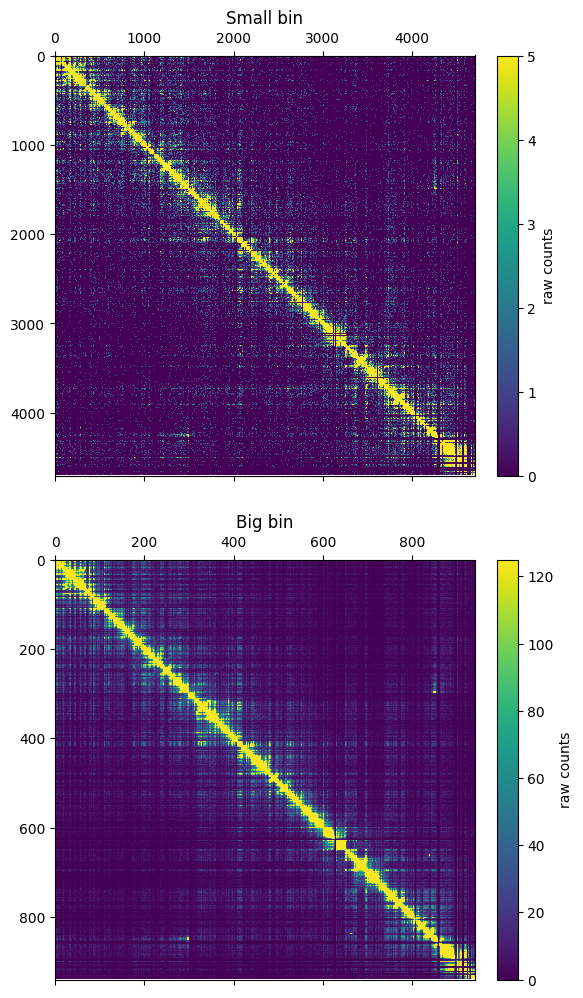

In [9]:
vmax = 5
f, ax = plt.subplots(2, 1, figsize=(7,6 * 2))

im_1 = ax[0].matshow(mtr_for_1, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0])
ax[0].xaxis.set_label_position('top')
ax[0].set_title('Small bin')

im_2 = ax[1].matshow(mtr_for_25, vmax=vmax*25)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1])
ax[1].xaxis.set_label_position('top')
ax[1].set_title('Big bin')

plt.show()

In [28]:
center_region = np.array(
    [
        (.2, .4),
        (.0, .6)
    ]
)

center_region = (center_region + 0.025)//0.05 * 0.05

def compute_scale_for_centers(areas):
    pass

In [ ]:
BIN = (250, 255)
WINDOW = 4

zomified = mtr_for_25[BIN[0] - WINDOW: BIN[0] + WINDOW + 1, BIN[1] - WINDOW: BIN[1] + WINDOW + 1]
sz = zomified.sum()
rz = mtr_for_1[
    (BIN[0] - WINDOW) * 5:(BIN[0] + WINDOW + 1)*5, (BIN[1] - WINDOW) * 5:(BIN[1] + WINDOW + 1)*5]
zoomed = zoom(zomified, zoom=5, order=5)

In [143]:
zomified

array([[  810,   656,   456,   251,   244,   176,    34,    93,    49],
       [  904,   712,   508,   261,   316,   189,    52,   114,    62],
       [ 1107,   805,   507,   273,   284,   199,    41,   107,    59],
       [  809,   559,   343,   161,   198,   140,    28,    84,    44],
       [ 2157,  1042,   677,   334,   301,   262,    38,   139,    71],
       [ 3422,  1691,   884,   374,   321,   261,    60,   185,    74],
       [ 1691,  2967,  1996,   385,   264,   246,    54,   175,    84],
       [  884,  1996, 14882,  3555,   761,  1438,   473,   966,   476],
       [  374,   385,  3555,  5761,  3054,  1659,   216,   550,   195]],
      dtype=int32)

In [142]:
zoomed

array([[810, 803, 782, ...,  63,  53,  49],
       [810, 803, 782, ...,  64,  54,  50],
       [811, 804, 782, ...,  66,  56,  52],
       ...,
       [482, 413, 249, ..., 400, 308, 273],
       [403, 366, 276, ..., 336, 249, 216],
       [374, 349, 288, ..., 312, 227, 195]], shape=(45, 45), dtype=int32)

In [128]:
tz = zoomed/zoomed.sum() * sz

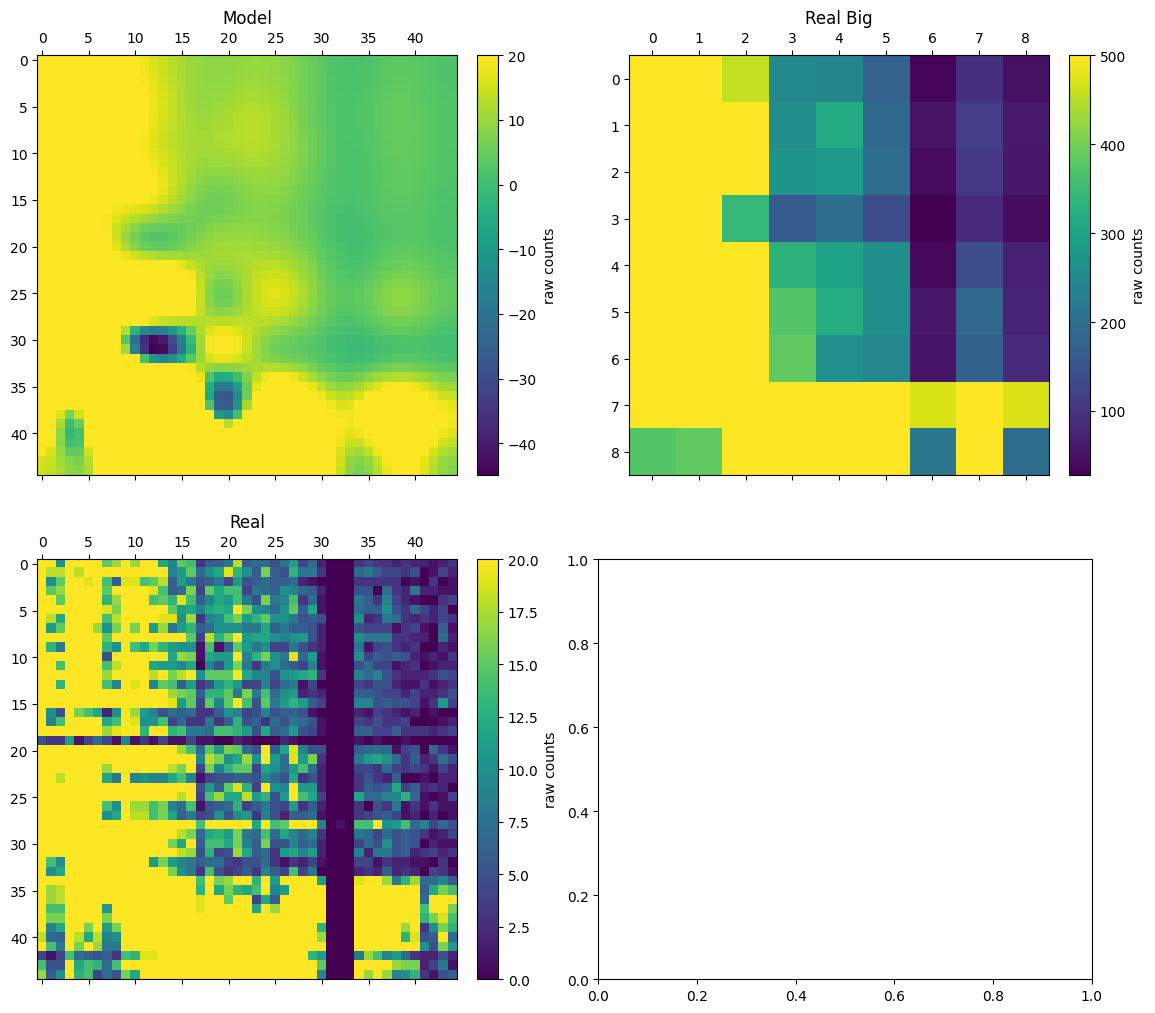

In [135]:
vmax = 20
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(tz, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Model')

im_2 = ax[1][0].matshow(rz, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Real')

im_3 = ax[0][1].matshow(zomified, vmax=vmax*25)
plt.colorbar(im_3 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][1])
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_title('Real Big')


plt.show()

In [130]:
def fit_plane(counts):
    n, m = counts.shape
    assert n == m and n % 2 == 1
    A = []
    b = []
    for i in range(n):
        for j in range(n):
            x = i + 0.5  
            y = j + 0.5  
            A.append([x, y, 1])
            b.append(counts[i, j])
    A = np.array(A)
    b = np.array(b)
    coeffs, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    a, b_coef, c = coeffs
    return float(a), float(b_coef), float(c)


def integrate_plane(coeffs, region):
    a, b, c = coeffs
    x0, x1 = region[0]
    y0, y1 = region[1]
    I = a * (x1**2 - x0**2) / 2 * (y1 - y0) \
      + b * (y1**2 - y0**2) / 2 * (x1 - x0) \
      + c * (x1 - x0) * (y1 - y0)
    return I

In [125]:
coeffs = fit_plane(zomified)

In [139]:
new_c = np.zeros(((WINDOW*2 + 1)*5, (WINDOW*2 + 1)*5))

for x_c, y_c in it.product(range((WINDOW*2 + 1)*5), range((WINDOW*2 + 1)*5)):
    int_value = integrate_plane(coeffs, ((x_c/5, x_c/5 + 0.2), (y_c/5, y_c/5 + 0.2)))
    full_sq_value = integrate_plane(coeffs, ((x_c//5, x_c//5 + 1), (y_c//5, y_c//5 + 1)))
    real_big_value = zomified[x_c//5, y_c//5]
    new_c[x_c, y_c] = real_big_value * (int_value/full_sq_value)

In [140]:
new_c

array([[21.61815126, 22.92504202, 24.23193277, ...,  1.77093248,
         1.80118328,  1.83143408],
       [25.70218487, 27.00907563, 28.31596639, ...,  1.86546624,
         1.89571704,  1.92596785],
       [29.78621849, 31.09310924, 32.4       , ...,  1.96      ,
         1.9902508 ,  2.02050161],
       ...,
       [14.76025591, 14.86012796, 14.96      , ...,  7.8       ,
         7.84109769,  7.88219539],
       [15.07235605, 15.17222809, 15.27210014, ...,  7.9284303 ,
         7.96952799,  8.01062569],
       [15.38445619, 15.48432823, 15.58420028, ...,  8.05686059,
         8.09795829,  8.13905598]], shape=(45, 45))

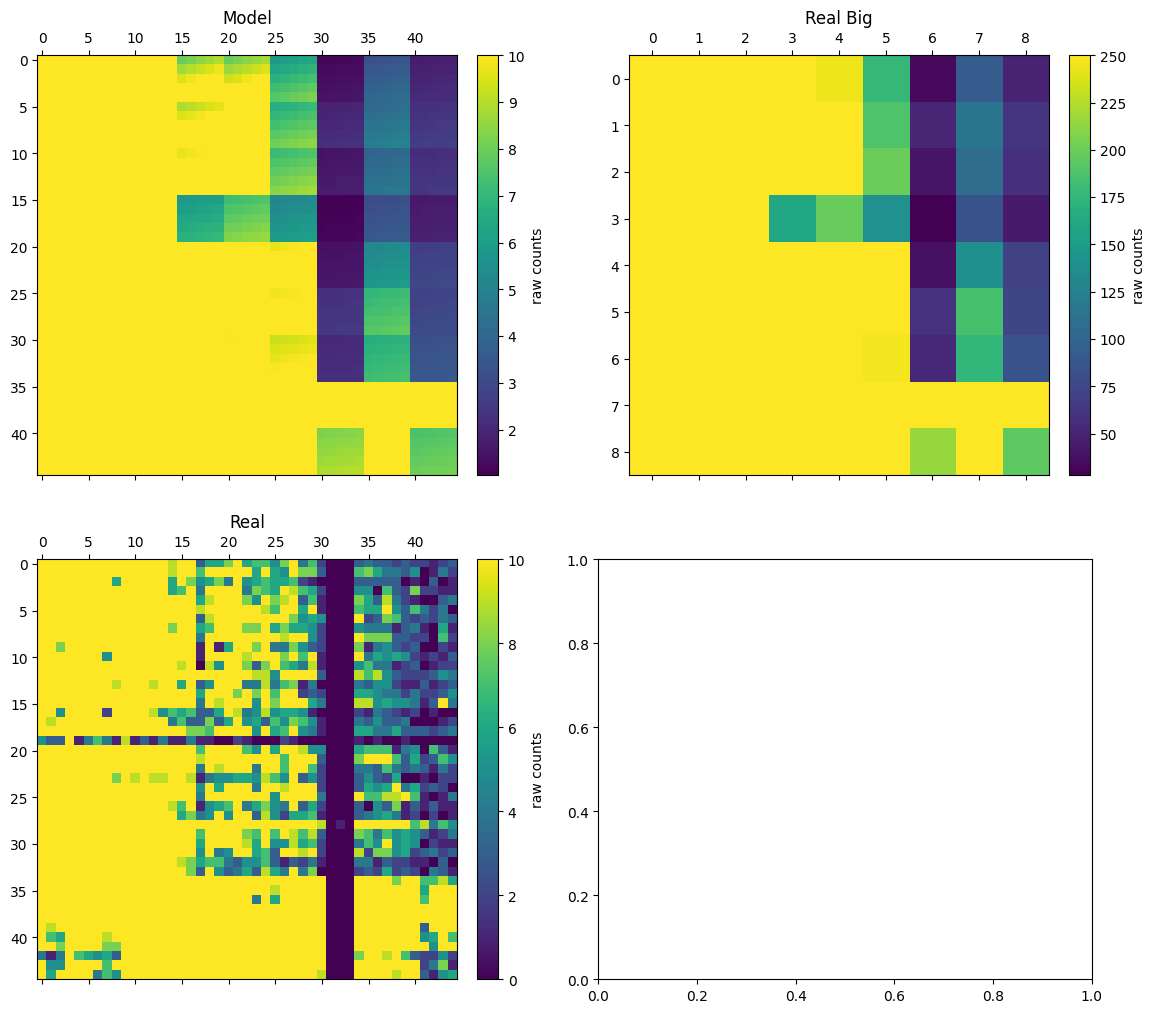

In [141]:
vmax = 10
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(new_c, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Model')

im_2 = ax[1][0].matshow(rz, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Real')

im_3 = ax[0][1].matshow(zomified, vmax=vmax*25)
plt.colorbar(im_3 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][1])
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_title('Real Big')


plt.show()

In [102]:
for i in it.product('1234', '23465'):
    print(i)

('1', '2')
('1', '3')
('1', '4')
('1', '6')
('1', '5')
('2', '2')
('2', '3')
('2', '4')
('2', '6')
('2', '5')
('3', '2')
('3', '3')
('3', '4')
('3', '6')
('3', '5')
('4', '2')
('4', '3')
('4', '4')
('4', '6')
('4', '5')
